In [1]:
"""
================================================================================
IDEAL FUNCTION FITTING AND TEST DATA MAPPING
================================================================================

Course: DLMDSPWP01 - Programming with Python
Assignment: Written Assignment - Ideal Function Selection
Student: Yuvraj Shekhar
Matriculation Number: 10244366
Tutor: Ugur Ural
Date: 29/07/2025

Description:
This notebook implements a comprehensive solution for selecting optimal ideal
functions from a set of 50 candidates using least squares regression, and
mapping test data points based on statistical deviation criteria.

================================================================================
"""

'\n================================================================================\nIDEAL FUNCTION FITTING AND TEST DATA MAPPING\n================================================================================\n\nCourse: DLMDSPWP01 - Programming with Python\nAssignment: Written Assignment - Ideal Function Selection\nStudent: Yuvraj Shekhar\nMatriculation Number: 10244366\nTutor: Ugur Ural\nDate: 29/07/2025\n\nDescription:\nThis notebook implements a comprehensive solution for selecting optimal ideal\nfunctions from a set of 50 candidates using least squares regression, and \nmapping test data points based on statistical deviation criteria.\n\n================================================================================\n'

In [3]:
# Install required packages that are not pre-installed in Colab
!pip install -q bokeh sqlalchemy

print("Required packages installed successfully")

Required packages installed successfully


In [4]:
# Standard library imports
import pandas as pd
import numpy as np
import sqlite3
import math
import unittest
import logging
from typing import List, Tuple, Dict, Optional
from io import BytesIO

# Database and ORM
from sqlalchemy import create_engine, Column, Integer, Float, MetaData, Table
from sqlalchemy.ext.declarative import declarative_base

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot
from bokeh.io import output_notebook

# Colab-specific imports
from google.colab import files

# Configure visualization settings
output_notebook()
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

print("All libraries imported successfully")

All libraries imported successfully


In [9]:
print("=" * 60)
print("DATA UPLOAD")
print("=" * 60)
print("\nPlease upload the following CSV files:")
print("  1. train.csv - Training data with 4 functions")
print("  2. test.csv - Test data points")
print("  3. ideal.csv - 50 ideal functions")
print()

uploaded = files.upload()

print(f"\nSuccessfully uploaded {len(uploaded)} files")
for filename in uploaded.keys():
    print(f"  • {filename}: {len(uploaded[filename]):,} bytes")

DATA UPLOAD

Please upload the following CSV files:
  1. train.csv - Training data with 4 functions
  2. test.csv - Test data points
  3. ideal.csv - 50 ideal functions



Saving ideal.csv to ideal.csv
Saving test.csv to test.csv
Saving train.csv to train.csv

Successfully uploaded 3 files
  • ideal.csv: 176,392 bytes
  • test.csv: 1,647 bytes
  • train.csv: 19,214 bytes


In [10]:
class DataLoadError(Exception):
    """Exception raised when data loading operations fail."""
    pass

class FittingError(Exception):
    """Exception raised when function fitting operations fail."""
    pass

class MappingError(Exception):
    """Exception raised when test data mapping operations fail."""
    pass

print("Custom exception classes defined")

Custom exception classes defined


In [11]:
class DataManager:
    """
    Manages data loading, database operations, and data persistence.

    This class handles all database operations using SQLAlchemy ORM and
    provides methods for loading CSV files and storing results.

    Attributes:
        db_path (str): Path to the SQLite database file
        engine: SQLAlchemy database engine
        metadata: SQLAlchemy metadata object
    """

    def __init__(self, db_path: str = "assignment_data.db"):
        """
        Initialize DataManager with database connection.

        Args:
            db_path: Path to SQLite database file
        """
        self.db_path = db_path
        self.engine = create_engine(f'sqlite:///{db_path}')
        self.metadata = MetaData()
        self.setup_database()

    def setup_database(self) -> None:
        """Create database tables if they don't exist."""
        try:
            # Training data table: x, y1, y2, y3, y4
            self.training_table = Table(
                'training_data', self.metadata,
                Column('x', Float, primary_key=True),
                Column('y1', Float),
                Column('y2', Float),
                Column('y3', Float),
                Column('y4', Float)
            )

            # Ideal functions table: x, y1...y50
            columns = [Column('x', Float, primary_key=True)]
            for i in range(1, 51):
                columns.append(Column(f'y{i}', Float))
            self.ideal_table = Table('ideal_functions', self.metadata, *columns)

            # Test results table
            self.test_results_table = Table(
                'test_results', self.metadata,
                Column('id', Integer, primary_key=True, autoincrement=True),
                Column('x', Float),
                Column('y', Float),
                Column('delta_y', Float),
                Column('ideal_func_number', Integer)
            )

            self.metadata.create_all(self.engine)
            logger.info("Database tables created successfully")

        except Exception as e:
            raise DataLoadError(f"Database setup failed: {str(e)}")

    def load_csv_data(self, uploaded_files: dict) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        Load data from uploaded CSV files.

        Args:
            uploaded_files: Dictionary of uploaded files from Colab

        Returns:
            Tuple containing training, test, and ideal dataframes

        Raises:
            DataLoadError: If file loading fails
        """
        try:
            # Find files by name pattern
            train_file = test_file = ideal_file = None

            for filename, content in uploaded_files.items():
                if 'train' in filename.lower():
                    train_file = content
                elif 'test' in filename.lower():
                    test_file = content
                elif 'ideal' in filename.lower():
                    ideal_file = content

            if not all([train_file, test_file, ideal_file]):
                raise DataLoadError("Could not find all required CSV files")

            # Load dataframes
            train_data = pd.read_csv(BytesIO(train_file))
            test_data = pd.read_csv(BytesIO(test_file))
            ideal_data = pd.read_csv(BytesIO(ideal_file))

            logger.info(f"Loaded training data: {train_data.shape}")
            logger.info(f"Loaded test data: {test_data.shape}")
            logger.info(f"Loaded ideal data: {ideal_data.shape}")

            return train_data, test_data, ideal_data

        except Exception as e:
            raise DataLoadError(f"CSV loading failed: {str(e)}")

    def save_to_database(self, train_data: pd.DataFrame, ideal_data: pd.DataFrame) -> None:
        """
        Save training and ideal data to database.

        Args:
            train_data: Training functions dataframe
            ideal_data: Ideal functions dataframe
        """
        try:
            train_data.to_sql('training_data', self.engine, if_exists='replace', index=False)
            ideal_data.to_sql('ideal_functions', self.engine, if_exists='replace', index=False)
            logger.info("Data saved to database successfully")
        except Exception as e:
            raise DataLoadError(f"Database save failed: {str(e)}")

    def save_test_results(self, results: List[Dict]) -> None:
        """
        Save test mapping results to database.

        Args:
            results: List of dictionaries containing mapping results
        """
        try:
            if results:
                results_df = pd.DataFrame(results)
                results_df.to_sql('test_results', self.engine, if_exists='replace', index=False)
                logger.info(f"Saved {len(results)} test results to database")
        except Exception as e:
            raise DataLoadError(f"Test results save failed: {str(e)}")

print("✓ DataManager class defined")

✓ DataManager class defined


In [12]:
class FunctionFitter:
    """
    Performs least squares fitting to find optimal ideal functions.

    Implements the core algorithm for selecting the 4 best-fitting ideal
    functions from 50 candidates using least squares criteria.

    Attributes:
        train_data: Training functions dataframe
        ideal_data: Ideal functions dataframe
        best_fits: Dictionary of best fit results
        fit_metrics: Dictionary of fit quality metrics
    """

    def __init__(self, train_data: pd.DataFrame, ideal_data: pd.DataFrame):
        """
        Initialize FunctionFitter with training and ideal data.

        Args:
            train_data: DataFrame containing training functions
            ideal_data: DataFrame containing ideal functions
        """
        self.train_data = train_data
        self.ideal_data = ideal_data
        self.best_fits = {}
        self.fit_metrics = {}

    def calculate_least_squares_deviation(self, train_y: pd.Series, ideal_y: pd.Series) -> float:
        """
        Calculate sum of squared deviations between training and ideal functions.

        Args:
            train_y: Training function y-values
            ideal_y: Ideal function y-values

        Returns:
            Sum of squared deviations

        Raises:
            FittingError: If calculation fails
        """
        try:
            deviations = train_y - ideal_y
            return np.sum(deviations ** 2)
        except Exception as e:
            raise FittingError(f"Least squares calculation failed: {str(e)}")

    def find_best_fits(self) -> Dict[str, Dict]:
        """
        Find the best fitting ideal function for each training function.

        Uses least squares method to evaluate all 200 combinations
        (4 training × 50 ideal functions) and selects optimal matches.

        Returns:
            Dictionary mapping training functions to best ideal functions
        """
        try:
            training_functions = ['y1', 'y2', 'y3', 'y4']
            ideal_functions = [f'y{i}' for i in range(1, 51)]

            for train_func in training_functions:
                best_deviation = float('inf')
                best_ideal_func = None
                best_ideal_index = None

                # Evaluate all 50 ideal functions
                for i, ideal_func in enumerate(ideal_functions, 1):
                    deviation = self.calculate_least_squares_deviation(
                        self.train_data[train_func],
                        self.ideal_data[ideal_func]
                    )

                    if deviation < best_deviation:
                        best_deviation = deviation
                        best_ideal_func = ideal_func
                        best_ideal_index = i

                self.best_fits[train_func] = {
                    'ideal_function': best_ideal_func,
                    'ideal_index': best_ideal_index,
                    'deviation': best_deviation
                }

                logger.info(f"{train_func} → {best_ideal_func} (deviation: {best_deviation:.4f})")

            return self.best_fits

        except Exception as e:
            raise FittingError(f"Best fit calculation failed: {str(e)}")

    def get_max_deviations(self) -> Dict[str, float]:
        """
        Calculate maximum deviations for each training function fit.

        These values are used as thresholds for test data mapping.

        Returns:
            Dictionary of maximum deviations per training function
        """
        try:
            max_deviations = {}

            for train_func, fit_info in self.best_fits.items():
                ideal_func = fit_info['ideal_function']
                deviations = abs(self.train_data[train_func] - self.ideal_data[ideal_func])
                max_deviations[train_func] = deviations.max()

            return max_deviations

        except Exception as e:
            raise FittingError(f"Max deviation calculation failed: {str(e)}")

print("✓ FunctionFitter class defined")

✓ FunctionFitter class defined


In [13]:
class TestMapper:
    """
    Maps test data points to ideal functions using sqrt(2) criterion.

    Implements the mapping algorithm that assigns test points to ideal
    functions when deviation is within sqrt(2) × max_training_deviation.

    Attributes:
        test_data: Test data points
        ideal_data: Ideal functions data
        best_fits: Selected ideal functions
        max_deviations: Maximum training deviations
        sqrt_2: Square root of 2 constant
    """

    def __init__(self, test_data: pd.DataFrame, ideal_data: pd.DataFrame,
                 best_fits: Dict, max_deviations: Dict):
        """
        Initialize TestMapper with necessary data.

        Args:
            test_data: Test points dataframe
            ideal_data: Ideal functions dataframe
            best_fits: Best fitting ideal functions
            max_deviations: Maximum deviations from training
        """
        self.test_data = test_data
        self.ideal_data = ideal_data
        self.best_fits = best_fits
        self.max_deviations = max_deviations
        self.sqrt_2 = math.sqrt(2)

    def map_test_point(self, x_test: float, y_test: float) -> Optional[Dict]:
        """
        Attempt to map a single test point to an ideal function.

        Args:
            x_test: Test point x-coordinate
            y_test: Test point y-coordinate

        Returns:
            Mapping dictionary if successful, None otherwise
        """
        try:
            # Find closest x-value in ideal data
            x_diff = abs(self.ideal_data['x'] - x_test)
            closest_idx = x_diff.idxmin()

            best_mapping = None
            min_deviation = float('inf')

            # Check all four selected ideal functions
            for train_func, fit_info in self.best_fits.items():
                ideal_func = fit_info['ideal_function']
                ideal_index = fit_info['ideal_index']

                # Get ideal function value at test x-coordinate
                ideal_y = self.ideal_data.loc[closest_idx, ideal_func]

                # Calculate deviation
                deviation = abs(y_test - ideal_y)

                # Check sqrt(2) criterion
                max_allowed_deviation = self.max_deviations[train_func] * self.sqrt_2

                if deviation <= max_allowed_deviation and deviation < min_deviation:
                    min_deviation = deviation
                    best_mapping = {
                        'x': x_test,
                        'y': y_test,
                        'delta_y': deviation,
                        'ideal_func_number': ideal_index
                    }

            return best_mapping

        except Exception as e:
            raise MappingError(f"Test point mapping failed: {str(e)}")

    def map_all_test_data(self) -> List[Dict]:
        """
        Map all test data points to ideal functions.

        Returns:
            List of successful mappings
        """
        try:
            mappings = []

            for _, row in self.test_data.iterrows():
                mapping = self.map_test_point(row['x'], row['y'])
                if mapping:
                    mappings.append(mapping)

            success_rate = (len(mappings) / len(self.test_data)) * 100
            logger.info(f"Mapped {len(mappings)}/{len(self.test_data)} points ({success_rate:.1f}%)")

            return mappings

        except Exception as e:
            raise MappingError(f"Bulk test mapping failed: {str(e)}")

print("✓ TestMapper class defined")


✓ TestMapper class defined


In [18]:
class Visualizer:
    """
    Creates comprehensive visualizations for analysis results.

    Generates both static (Matplotlib) and interactive (Bokeh) plots
    for training data, ideal functions, test mappings, and deviations.

    Attributes:
        train_data: Training functions
        ideal_data: Ideal functions
        test_data: Test points
        best_fits: Selected ideal functions
        mappings: Test mapping results
    """

    def __init__(self, train_data: pd.DataFrame, ideal_data: pd.DataFrame,
                 test_data: pd.DataFrame, best_fits: Dict, mappings: List[Dict]):
        """
        Initialize Visualizer with all necessary data.

        Args:
            train_data: Training data
            ideal_data: Ideal functions data
            test_data: Test data
            best_fits: Best fit results
            mappings: Test mapping results
        """
        self.train_data = train_data
        self.ideal_data = ideal_data
        self.test_data = test_data
        self.best_fits = best_fits
        self.mappings = mappings

    def create_comprehensive_dashboard(self):
        """
        Create 4-panel Matplotlib dashboard with all analysis views.

        Generates:
        - Training vs ideal functions comparison
        - Test data mapping results
        - Deviation scatter plot
        - Deviation distribution histogram
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Ideal Function Fitting and Test Data Mapping - Complete Analysis',
                     fontsize=16, fontweight='bold')

        colors = ['red', 'blue', 'green', 'orange']

        # Panel 1: Training vs Ideal Functions
        ax1 = axes[0, 0]
        for train_func, color in zip(['y1', 'y2', 'y3', 'y4'], colors):
            ax1.plot(self.train_data['x'], self.train_data[train_func],
                    color=color, linewidth=2, label=f'Training {train_func}')

            ideal_func = self.best_fits[train_func]['ideal_function']
            ax1.plot(self.ideal_data['x'], self.ideal_data[ideal_func],
                    color=color, linestyle='--', linewidth=2, alpha=0.7,
                    label=f'Ideal {ideal_func}')

        ax1.set_title('Training Data vs Best-Fit Ideal Functions', fontsize=12, fontweight='bold')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.3)

        # Panel 2: Test Data Mapping
        ax2 = axes[0, 1]
        if self.mappings:
            mapping_df = pd.DataFrame(self.mappings)
            ax2.scatter(mapping_df['x'], mapping_df['y'],
                       c='red', s=50, alpha=0.7, label='Mapped Points')

            # Unmapped points
            mapped_indices = set()
            for mapping in self.mappings:
                mask = (abs(self.test_data['x'] - mapping['x']) < 1e-10) & \
                       (abs(self.test_data['y'] - mapping['y']) < 1e-10)
                if mask.any():
                    mapped_indices.add(mask.idxmax())

            unmapped_data = self.test_data.drop(list(mapped_indices))
            if not unmapped_data.empty:
                ax2.scatter(unmapped_data['x'], unmapped_data['y'],
                           c='gray', s=50, alpha=0.7, label='Unmapped Points')

        ax2.set_title('Test Data Mapping Results', fontsize=12, fontweight='bold')
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Panel 3: Deviation Analysis
        ax3 = axes[1, 0]
        if self.mappings:
            mapping_df = pd.DataFrame(self.mappings)
            ax3.scatter(mapping_df['x'], mapping_df['delta_y'],
                       c='blue', s=50, alpha=0.7)
            mean_dev = mapping_df['delta_y'].mean()
            ax3.axhline(y=mean_dev, color='red', linestyle='--',
                       label=f'Mean: {mean_dev:.4f}')

        ax3.set_title('Deviation Analysis', fontsize=12, fontweight='bold')
        ax3.set_xlabel('X')
        ax3.set_ylabel('Deviation')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Panel 4: Deviation Distribution
        ax4 = axes[1, 1]
        if self.mappings:
            mapping_df = pd.DataFrame(self.mappings)
            ax4.hist(mapping_df['delta_y'], bins=20, alpha=0.7,
                    color='skyblue', edgecolor='black')
            ax4.axvline(mapping_df['delta_y'].mean(), color='red',
                       linestyle='--', label=f"Mean: {mapping_df['delta_y'].mean():.4f}")
            ax4.axvline(mapping_df['delta_y'].median(), color='green',
                       linestyle='--', label=f"Median: {mapping_df['delta_y'].median():.4f}")

        ax4.set_title('Distribution of Deviations', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Deviation')
        ax4.set_ylabel('Frequency')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def create_interactive_plots(self):
        """
        Create interactive Bokeh visualizations.

        Generates two interactive plots:
        - Training data with ideal functions
        - Test data mapping results
        """
        # Training functions plot
        p1 = figure(title="Training Data vs Best-Fit Ideal Functions",
                   x_axis_label='X', y_axis_label='Y',
                   width=700, height=400)

        colors = ['red', 'blue', 'green', 'orange']

        for train_func, color in zip(['y1', 'y2', 'y3', 'y4'], colors):
            p1.line(self.train_data['x'], self.train_data[train_func],
                   legend_label=f'Training {train_func}',
                   color=color, line_width=2)

            ideal_func = self.best_fits[train_func]['ideal_function']
            p1.line(self.ideal_data['x'], self.ideal_data[ideal_func],
                   legend_label=f'Ideal {ideal_func}',
                   color=color, line_dash='dashed', line_width=2)

        p1.legend.location = "top_left"
        p1.legend.click_policy = "hide"

        # Test mapping plot
        p2 = figure(title="Test Data Mapping Results",
                   x_axis_label='X', y_axis_label='Y',
                   width=700, height=400)

        if self.mappings:
            mapping_df = pd.DataFrame(self.mappings)
            p2.scatter(mapping_df['x'], mapping_df['y'],
                      size=8, color='red', alpha=0.6,
                      legend_label='Mapped Points')

            # Unmapped points
            mapped_indices = set()
            for mapping in self.mappings:
                mask = (abs(self.test_data['x'] - mapping['x']) < 1e-10) & \
                       (abs(self.test_data['y'] - mapping['y']) < 1e-10)
                if mask.any():
                    mapped_indices.add(mask.idxmax())

            unmapped_data = self.test_data.drop(list(mapped_indices))
            if not unmapped_data.empty:
                p2.scatter(unmapped_data['x'], unmapped_data['y'],
                          size=8, color='gray', alpha=0.6,
                          legend_label='Unmapped Points')

        p2.legend.location = "top_left"

        # Display plots
        show(gridplot([[p1], [p2]]))

print("✓ Visualizer class defined")

✓ Visualizer class defined


In [19]:
def run_analysis():
    """
    Execute the complete analysis pipeline.

    Performs all steps from data loading through visualization:
    1. Load CSV data
    2. Create database and store data
    3. Find best-fit ideal functions
    4. Map test data points
    5. Save results
    6. Generate visualizations

    Returns:
        Dictionary containing all analysis results
    """
    print("\n" + "=" * 70)
    print("IDEAL FUNCTION FITTING AND TEST DATA MAPPING ANALYSIS")
    print("=" * 70)

    try:
        # Step 1: Initialize Data Manager
        print("\n[1/7] Initializing Data Manager...")
        data_manager = DataManager()

        # Step 2: Load Data
        print("[2/7] Loading CSV Data...")
        train_data, test_data, ideal_data = data_manager.load_csv_data(uploaded)
        print(f"  • Training data: {train_data.shape}")
        print(f"  • Test data: {test_data.shape}")
        print(f"  • Ideal data: {ideal_data.shape}")

        # Step 3: Save to Database
        print("[3/7] Saving to Database...")
        data_manager.save_to_database(train_data, ideal_data)

        # Step 4: Find Best Fits
        print("[4/7] Finding Best-Fit Ideal Functions...")
        fitter = FunctionFitter(train_data, ideal_data)
        best_fits = fitter.find_best_fits()
        max_deviations = fitter.get_max_deviations()

        # Step 5: Map Test Data
        print("[5/7] Mapping Test Data...")
        mapper = TestMapper(test_data, ideal_data, best_fits, max_deviations)
        mappings = mapper.map_all_test_data()

        # Step 6: Save Results
        print("[6/7] Saving Results to Database...")
        data_manager.save_test_results(mappings)

        # Step 7: Create Visualizations
        print("[7/7] Generating Visualizations...")
        visualizer = Visualizer(train_data, ideal_data, test_data, best_fits, mappings)

        # Display Summary
        print("\n" + "=" * 70)
        print("ANALYSIS SUMMARY")
        print("=" * 70)
        print(f"Training functions analyzed: 4")
        print(f"Ideal functions evaluated: 50")
        print(f"Test data points: {len(test_data)}")
        print(f"Successfully mapped points: {len(mappings)}")
        print(f"Mapping success rate: {len(mappings)/len(test_data)*100:.1f}%")

        print(f"\nBest Fitting Functions:")
        for train_func, fit_info in best_fits.items():
            print(f"  {train_func} → {fit_info['ideal_function']} "
                  f"(deviation: {fit_info['deviation']:.4f})")

        print(f"\nSqrt(2) Criterion Thresholds:")
        for train_func, max_dev in max_deviations.items():
            threshold = max_dev * math.sqrt(2)
            print(f"  {train_func}: max_dev={max_dev:.4f}, threshold={threshold:.4f}")

        if mappings:
            mapping_df = pd.DataFrame(mappings)
            print(f"\nMapping Statistics:")
            print(f"  Mean deviation: {mapping_df['delta_y'].mean():.4f}")
            print(f"  Median deviation: {mapping_df['delta_y'].median():.4f}")
            print(f"  Max deviation: {mapping_df['delta_y'].max():.4f}")
            print(f"  Min deviation: {mapping_df['delta_y'].min():.4f}")

        print("\n" + "=" * 70)
        print("Generating Matplotlib Dashboard...")
        print("=" * 70)
        visualizer.create_comprehensive_dashboard()

        print("\n" + "=" * 70)
        print("Generating Interactive Bokeh Plots...")
        print("=" * 70)
        visualizer.create_interactive_plots()

        print("\nAnalysis completed successfully!")
        print("=" * 70)

        return {
            'train_data': train_data,
            'test_data': test_data,
            'ideal_data': ideal_data,
            'best_fits': best_fits,
            'mappings': mappings,
            'max_deviations': max_deviations
        }

    except Exception as e:
        print(f"\nAnalysis failed: {str(e)}")
        import traceback
        traceback.print_exc()
        raise

print("Main analysis function defined")


Main analysis function defined


In [20]:
class TestAnalysisPipeline(unittest.TestCase):
    """Unit tests for the analysis pipeline components."""

    def setUp(self):
        """Set up test fixtures."""
        self.sample_train = pd.DataFrame({
            'x': [1.0, 2.0, 3.0],
            'y1': [1.0, 4.0, 9.0],
            'y2': [1.0, 2.0, 3.0],
            'y3': [2.0, 4.0, 6.0],
            'y4': [1.0, 8.0, 27.0]
        })

        self.sample_ideal = pd.DataFrame({
            'x': [1.0, 2.0, 3.0],
            'y1': [1.0, 4.0, 9.0],
            'y2': [1.0, 2.0, 3.0]
        })

    def test_least_squares_calculation(self):
        """Test least squares deviation calculation."""
        fitter = FunctionFitter(self.sample_train, self.sample_ideal)
        deviation = fitter.calculate_least_squares_deviation(
            self.sample_train['y1'],
            self.sample_ideal['y1']
        )
        self.assertAlmostEqual(deviation, 0.0, places=10)

    def test_data_manager_initialization(self):
        """Test DataManager initialization."""
        dm = DataManager("test.db")
        self.assertIsNotNone(dm.engine)
        self.assertIsNotNone(dm.metadata)

    def test_mathematical_operations(self):
        """Test basic mathematical operations."""
        y1 = pd.Series([1, 2, 3])
        y2 = pd.Series([1, 2, 3])
        deviation = np.sum((y1 - y2) ** 2)
        self.assertEqual(deviation, 0)

def run_tests():
    """Run unit tests and display results."""
    print("\n" + "=" * 70)
    print("UNIT TESTS")
    print("=" * 70)

    suite = unittest.TestLoader().loadTestsFromTestCase(TestAnalysisPipeline)
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)

    print("\n" + "=" * 70)
    print(f"Tests Run: {result.testsRun}")
    print(f"Failures: {len(result.failures)}")
    print(f"Errors: {len(result.errors)}")
    print(f"Success: {result.wasSuccessful()}")
    print("=" * 70)

    return result.wasSuccessful()

print("Unit tests defined")


Unit tests defined


test_data_manager_initialization (__main__.TestAnalysisPipeline.test_data_manager_initialization)
Test DataManager initialization. ... ok
test_least_squares_calculation (__main__.TestAnalysisPipeline.test_least_squares_calculation)
Test least squares deviation calculation. ... ok
test_mathematical_operations (__main__.TestAnalysisPipeline.test_mathematical_operations)
Test basic mathematical operations. ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.012s

OK


Step 1: Running Unit Tests

UNIT TESTS

Tests Run: 3
Failures: 0
Errors: 0
Success: True

All tests passed! Proceeding with analysis...

Step 2: Running Complete Analysis

IDEAL FUNCTION FITTING AND TEST DATA MAPPING ANALYSIS

[1/7] Initializing Data Manager...
[2/7] Loading CSV Data...
  • Training data: (400, 5)
  • Test data: (100, 2)
  • Ideal data: (400, 51)
[3/7] Saving to Database...
[4/7] Finding Best-Fit Ideal Functions...
[5/7] Mapping Test Data...
[6/7] Saving Results to Database...
[7/7] Generating Visualizations...

ANALYSIS SUMMARY
Training functions analyzed: 4
Ideal functions evaluated: 50
Test data points: 100
Successfully mapped points: 48
Mapping success rate: 48.0%

Best Fitting Functions:
  y1 → y42 (deviation: 34.2466)
  y2 → y41 (deviation: 35.6018)
  y3 → y11 (deviation: 29.8618)
  y4 → y48 (deviation: 31.9634)

Sqrt(2) Criterion Thresholds:
  y1: max_dev=0.4960, threshold=0.7014
  y2: max_dev=0.4977, threshold=0.7039
  y3: max_dev=0.4989, threshold=0.7056
  y4:

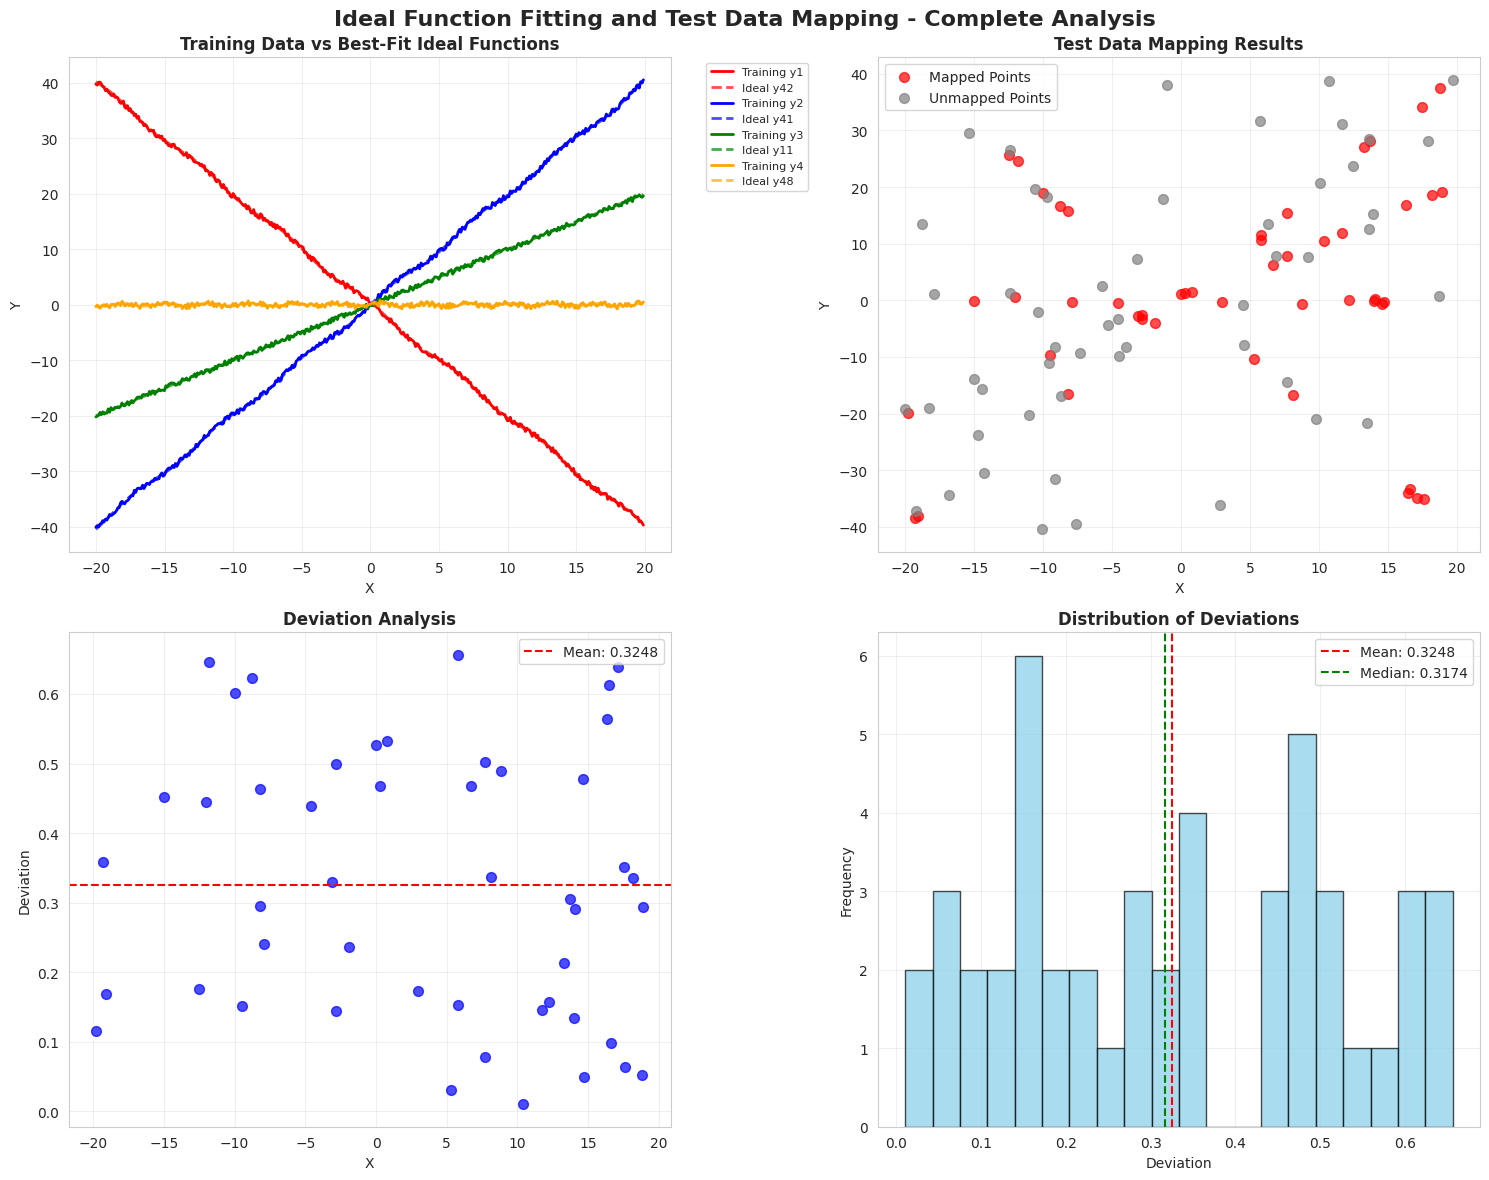


Generating Interactive Bokeh Plots...



Analysis completed successfully!

ANALYSIS COMPLETE

Database file 'assignment_data.db' has been created.
All visualizations have been generated above.


In [22]:
# Run unit tests first
print("Step 1: Running Unit Tests")
test_success = run_tests()

if test_success:
    print("\nAll tests passed! Proceeding with analysis...\n")
else:
    print("\nSome tests failed, but continuing with analysis...\n")

# Execute main analysis
print("Step 2: Running Complete Analysis")
results = run_analysis()

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print("\nDatabase file 'assignment_data.db' has been created.")
print("All visualizations have been generated above.")
print("=" * 70)